# Прогнозирование Оттока Клиентов в Телекоме

Этот ноутбук покрывает бизнес-постановку задачи, подготовку данных, exploratory data analysis и дизайн preprocessing для churn-моделирования. Цель — понять структуру оттока, собрать leakage-safe feature set и подготовить model-ready train/test data с интерпретируемыми preprocessing-решениями.

## 1. Бизнес-задача

Телеком-бизнесу важно заранее находить клиентов с повышенным риском оттока до того, как они отключат сервис. На практике такая модель должна поддерживать retention-кампании и распределение ограниченного бюджета.

На этом этапе мы еще не обучаем модели. Вместо этого мы разбираемся, как churn выглядит в данных, какие клиентские сегменты выглядят наиболее уязвимыми и какие решения по подготовке данных нужны, чтобы не получить искаженные результаты.

In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_preprocessing import clean_telco_data, load_raw_data, save_processed_data, validate_raw_schema
from src.features import (
    build_preprocessor,
    create_train_test_split,
    get_transformed_feature_names,
    infer_feature_groups,
    prepare_modeling_table,
    split_features_target,
)
from src.train import train_all_models
from src.evaluate import (
    aggregate_importance_by_feature_family,
    assign_risk_segments,
    build_threshold_metrics_table,
    build_metrics_table,
    calculate_metrics_at_threshold,
    find_optimal_threshold,
    get_confusion_matrix_frame,
    get_prediction_scores,
    get_roc_curve_data,
    summarize_feature_importance,
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "telco_churn_clean.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 2. Обзор датасета

In [3]:
df_raw = load_raw_data(RAW_DATA_PATH)
print(f"Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
schema_overview = pd.DataFrame(
    {
        "column": df_raw.columns,
        "dtype": df_raw.dtypes.astype(str).values,
        "n_unique": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
        "missing_na": [df_raw[col].isna().sum() for col in df_raw.columns],
        "blank_strings": [
            (df_raw[col].astype(str).str.strip() == "").sum() if df_raw[col].dtype == "object" else 0
            for col in df_raw.columns
        ],
    }
).sort_values(["dtype", "column"]).reset_index(drop=True)

display(schema_overview)
df_raw.info()

,column,dtype,n_unique,missing_na,blank_strings
0,MonthlyCharges,float64,1585,0,0
1,SeniorCitizen,int64,2,0,0
2,tenure,int64,73,0,0
3,Churn,str,2,0,0
4,Contract,str,3,0,0
5,Dependents,str,2,0,0
6,DeviceProtection,str,3,0,0
7,InternetService,str,3,0,0
8,MultipleLines,str,3,0,0
9,OnlineBackup,str,3,0,0


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Интерпретация

Датасет компактный и удобный с бизнес-точки зрения: одна строка соответствует одному клиенту, а признаки покрывают демографию, статус аккаунта, платежное поведение и подключенные сервисы. Большая часть переменных категориальная, что вполне ожидаемо для subscription-бизнеса.

Сразу выделяются два поля:

- `customerID` — это идентификатор, и его нельзя использовать как predictive feature.
- `TotalCharges` хранится как текст, а не как число. Это классическая проблема качества данных, которая может незаметно сломать EDA или моделирование, если не обработать ее заранее.

## 3. Проверки качества данных

In [5]:
duplicate_rows = int(df_raw.duplicated().sum())
duplicate_customer_ids = int(df_raw["customerID"].duplicated().sum())
blank_total_charges = int((df_raw["TotalCharges"].astype(str).str.strip() == "").sum())

quality_report = pd.Series(
    {
        "duplicate_rows": duplicate_rows,
        "duplicate_customer_ids": duplicate_customer_ids,
        "columns_with_na": int((df_raw.isna().sum() > 0).sum()),
        "blank_total_charges": blank_total_charges,
    },
    name="value",
)

display(quality_report.to_frame())
display(
    df_raw.loc[
        df_raw["TotalCharges"].astype(str).str.strip() == "",
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"],
    ]
)


,value
duplicate_rows,0
duplicate_customer_ids,0
columns_with_na,0
blank_total_charges,11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


### Интерпретация

Дубликатов по клиентам нет, а формальных `NaN`-значений тоже нет, что хорошо. Но датасет прячет пропуски внутри `TotalCharges` в виде пустых строк, а не настоящих null-значений.

Эти 11 записей относятся к клиентам с `tenure = 0`, то есть фактически к совершенно новым клиентам. С бизнес-точки зрения подстановка `TotalCharges = 0` выглядит более обоснованной, чем удаление строк, потому что нулевая накопленная выручка логично соответствует нулевому tenure.

Это важно, потому что удаление таких строк слегка занизило бы долю самых новых клиентов, а именно они часто являются чувствительной группой с точки зрения churn prevention.

In [6]:
validate_raw_schema(df_raw)
df = clean_telco_data(df_raw)
save_processed_data(df, PROCESSED_DATA_PATH)

print(f"Cleaned dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame(name="missing_after_cleaning"))

Cleaned dataset shape: 7043 rows x 22 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,"1,889.50",No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,"1,840.75",No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


,missing_after_cleaning
customerID,0
gender,0
Churn,0
TotalCharges,0
MonthlyCharges,0
PaymentMethod,0
PaperlessBilling,0
Contract,0
StreamingMovies,0
StreamingTV,0


### Решения по подготовке данных

- `TotalCharges` переводится в числовой тип, а пустые значения заменяются на `0.0` только для клиентов с нулевым tenure.
- `SeniorCitizen` переводится из `0/1` в `No/Yes`, чтобы признак вел себя как категориальный бизнес-атрибут, а не как псевдонепрерывная переменная.
- `ChurnFlag` добавляется как бинарный target-helper для будущего моделирования и более удобной агрегации.
- `customerID` остается в таблице для трассируемости, но позже должен быть исключен из моделирования, чтобы не допустить leakage через чистый идентификатор.

Эти преобразования намеренно консервативны: они исправляют явно проблемные поля, не добавляя искусственные признаки и не создавая target leakage.

## 4. Анализ target-переменной

,Churn,customers,share_pct
0,No,5174,73.46
1,Yes,1869,26.54


AttributeError: 'NoneType' object has no attribute 'remove'

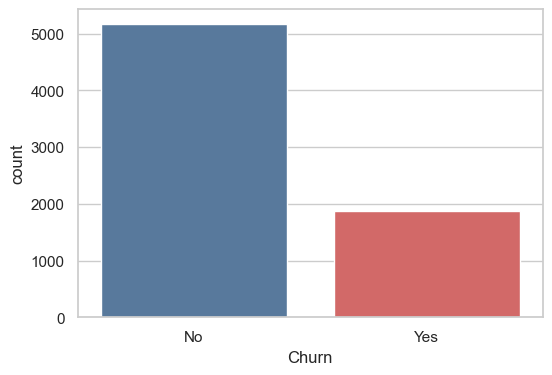

In [7]:
churn_distribution = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="customers")
)
churn_distribution["share_pct"] = (churn_distribution["customers"] / len(df) * 100).round(2)
display(churn_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], hue="Churn", dodge=False, palette=["#4c78a8", "#e45756"], ax=ax)
ax.legend_.remove()
ax.set_title("Target Distribution: Churn vs Non-Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Customers")
for patch in ax.patches:
    value = int(patch.get_height())
    ax.annotate(f"{value}", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom")
plt.tight_layout()

### Интерпретация и class imbalance

Target умеренно несбалансирован: около **73.5% non-churn против 26.5% churn**. Это не экстремальный дисбаланс, но он уже достаточно заметен, чтобы одна accuracy в дальнейшем вводила в заблуждение. Наивная модель, которая слишком уверенно предсказывает, что клиенты останутся, все еще может выглядеть неплохо по accuracy, но при этом пропускать слишком много клиентов с реальным риском ухода.

С бизнес-точки зрения такой дисбаланс сразу подчеркивает важность **recall**: false negatives означают, что мы не вмешались в судьбу клиентов, которые действительно уйдут. При этом дисбаланс не настолько сильный, чтобы до проверки сильных baseline-моделей требовались какие-то экзотические техники.

## 5. Исследовательский анализ данных

tenure              MonthlyCharges              TotalCharges           \
        mean median   std           mean median   std         mean   median   
Churn                                                                         
No     37.57  38.00 24.11          61.27  64.43 31.09     2,549.91 1,679.52   
Yes    17.98  10.00 19.53          74.44  79.65 24.67     1,531.80   703.55   

                
           std  
Churn           
No    2,329.95  
Yes   1,890.82

AttributeError: 'NoneType' object has no attribute 'remove'

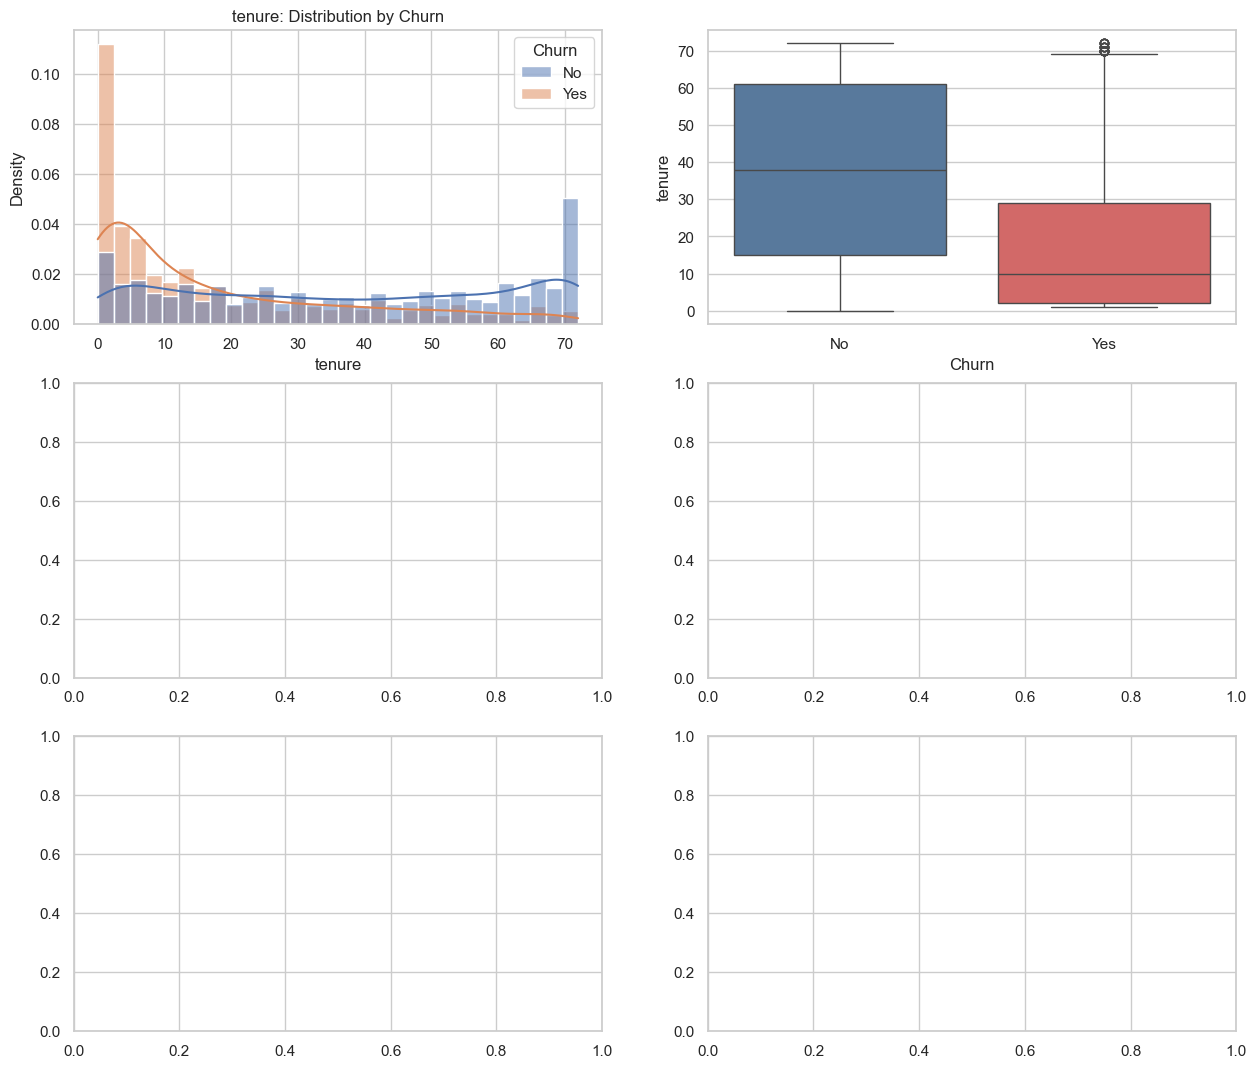

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

numeric_summary = (
    df.groupby("Churn")[numeric_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)
display(numeric_summary)

fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 13))
for row_idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, stat="density", common_norm=False, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"{col}: Distribution by Churn")
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], hue="Churn", dodge=False, palette=["#4c78a8", "#e45756"], ax=axes[row_idx, 1])
    axes[row_idx, 1].legend_.remove()
    axes[row_idx, 1].set_title(f"{col}: Boxplot by Churn")
plt.tight_layout()

### Интерпретация: числовые признаки

Числовая картина уже выглядит очень информативно:

- У клиентов, которые уходят, в среднем заметно **меньше tenure**, а значит early-life retention особенно важен.
- Churn-клиенты чаще имеют **более высокие monthly charges**, что может говорить о price sensitivity, более слабом ощущении ценности или концентрации в более дорогих сервисных пакетах.
- У churn-клиентов **ниже total charges**, но это не стоит трактовать как более низкий monetization potential. В первую очередь это следствие короткого tenure: они уходят раньше, чем успевают накопить долгосрочную выручку.

Для бизнеса это означает, что tenure и monthly charges, скорее всего, будут центральными переменными в любой proactive retention policy.

,TenureGroup,churn_rate,customers,churn_rate_pct
0,0-12 months,0.47,2186,47.44
1,13-24 months,0.29,1024,28.71
2,25-48 months,0.20,1594,20.39
3,49-72 months,0.10,2239,9.51


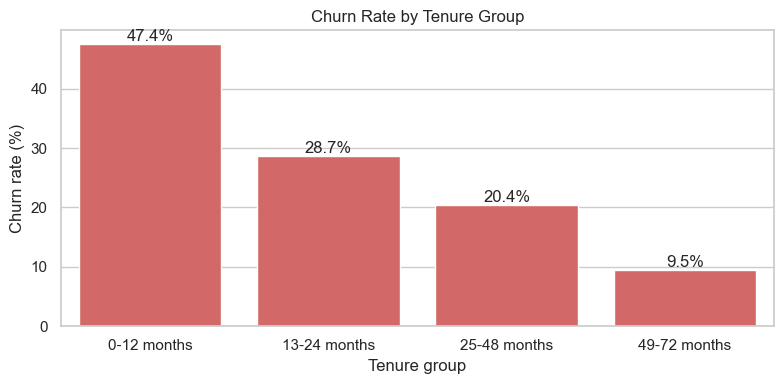

In [9]:
tenure_view = df.assign(
    TenureGroup=pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    )
)

tenure_churn = (
    tenure_view.groupby("TenureGroup", observed=False)["ChurnFlag"]
    .agg(churn_rate="mean", customers="size")
    .reset_index()
)
tenure_churn["churn_rate_pct"] = (tenure_churn["churn_rate"] * 100).round(2)
display(tenure_churn)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tenure_churn, x="TenureGroup", y="churn_rate_pct", color="#e45756", ax=ax)
ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("Tenure group")
ax.set_ylabel("Churn rate (%)")
for patch in ax.patches:
    value = patch.get_height()
    ax.annotate(f"{value:.1f}%", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom")
plt.tight_layout()

### Интерпретация: tenure как продуктовый сигнал

Первый год — это зона повышенного риска. У клиентов с tenure до 12 месяцев churn rate заметно выше, чем у long-tenure клиентов, которые уходят значительно реже.

Стратегически это очень важно: если retention-ресурсы ограничены, то onboarding и early-life engagement, вероятно, дадут больше эффекта, чем широкие и нетаргетированные кампании на всю клиентскую базу.

,feature,level,customers,churn_rate_pct
6,PaymentMethod,Electronic check,2365,45.29
0,Contract,Month-to-month,3875,42.71
3,InternetService,Fiber optic,3096,41.89
12,OnlineSecurity,No,3498,41.77
15,TechSupport,No,3473,41.64
10,PaperlessBilling,Yes,4171,33.57
18,Partner,No,3641,32.96
20,Dependents,No,4933,31.28
19,Partner,Yes,3402,19.66
7,PaymentMethod,Mailed check,1612,19.11


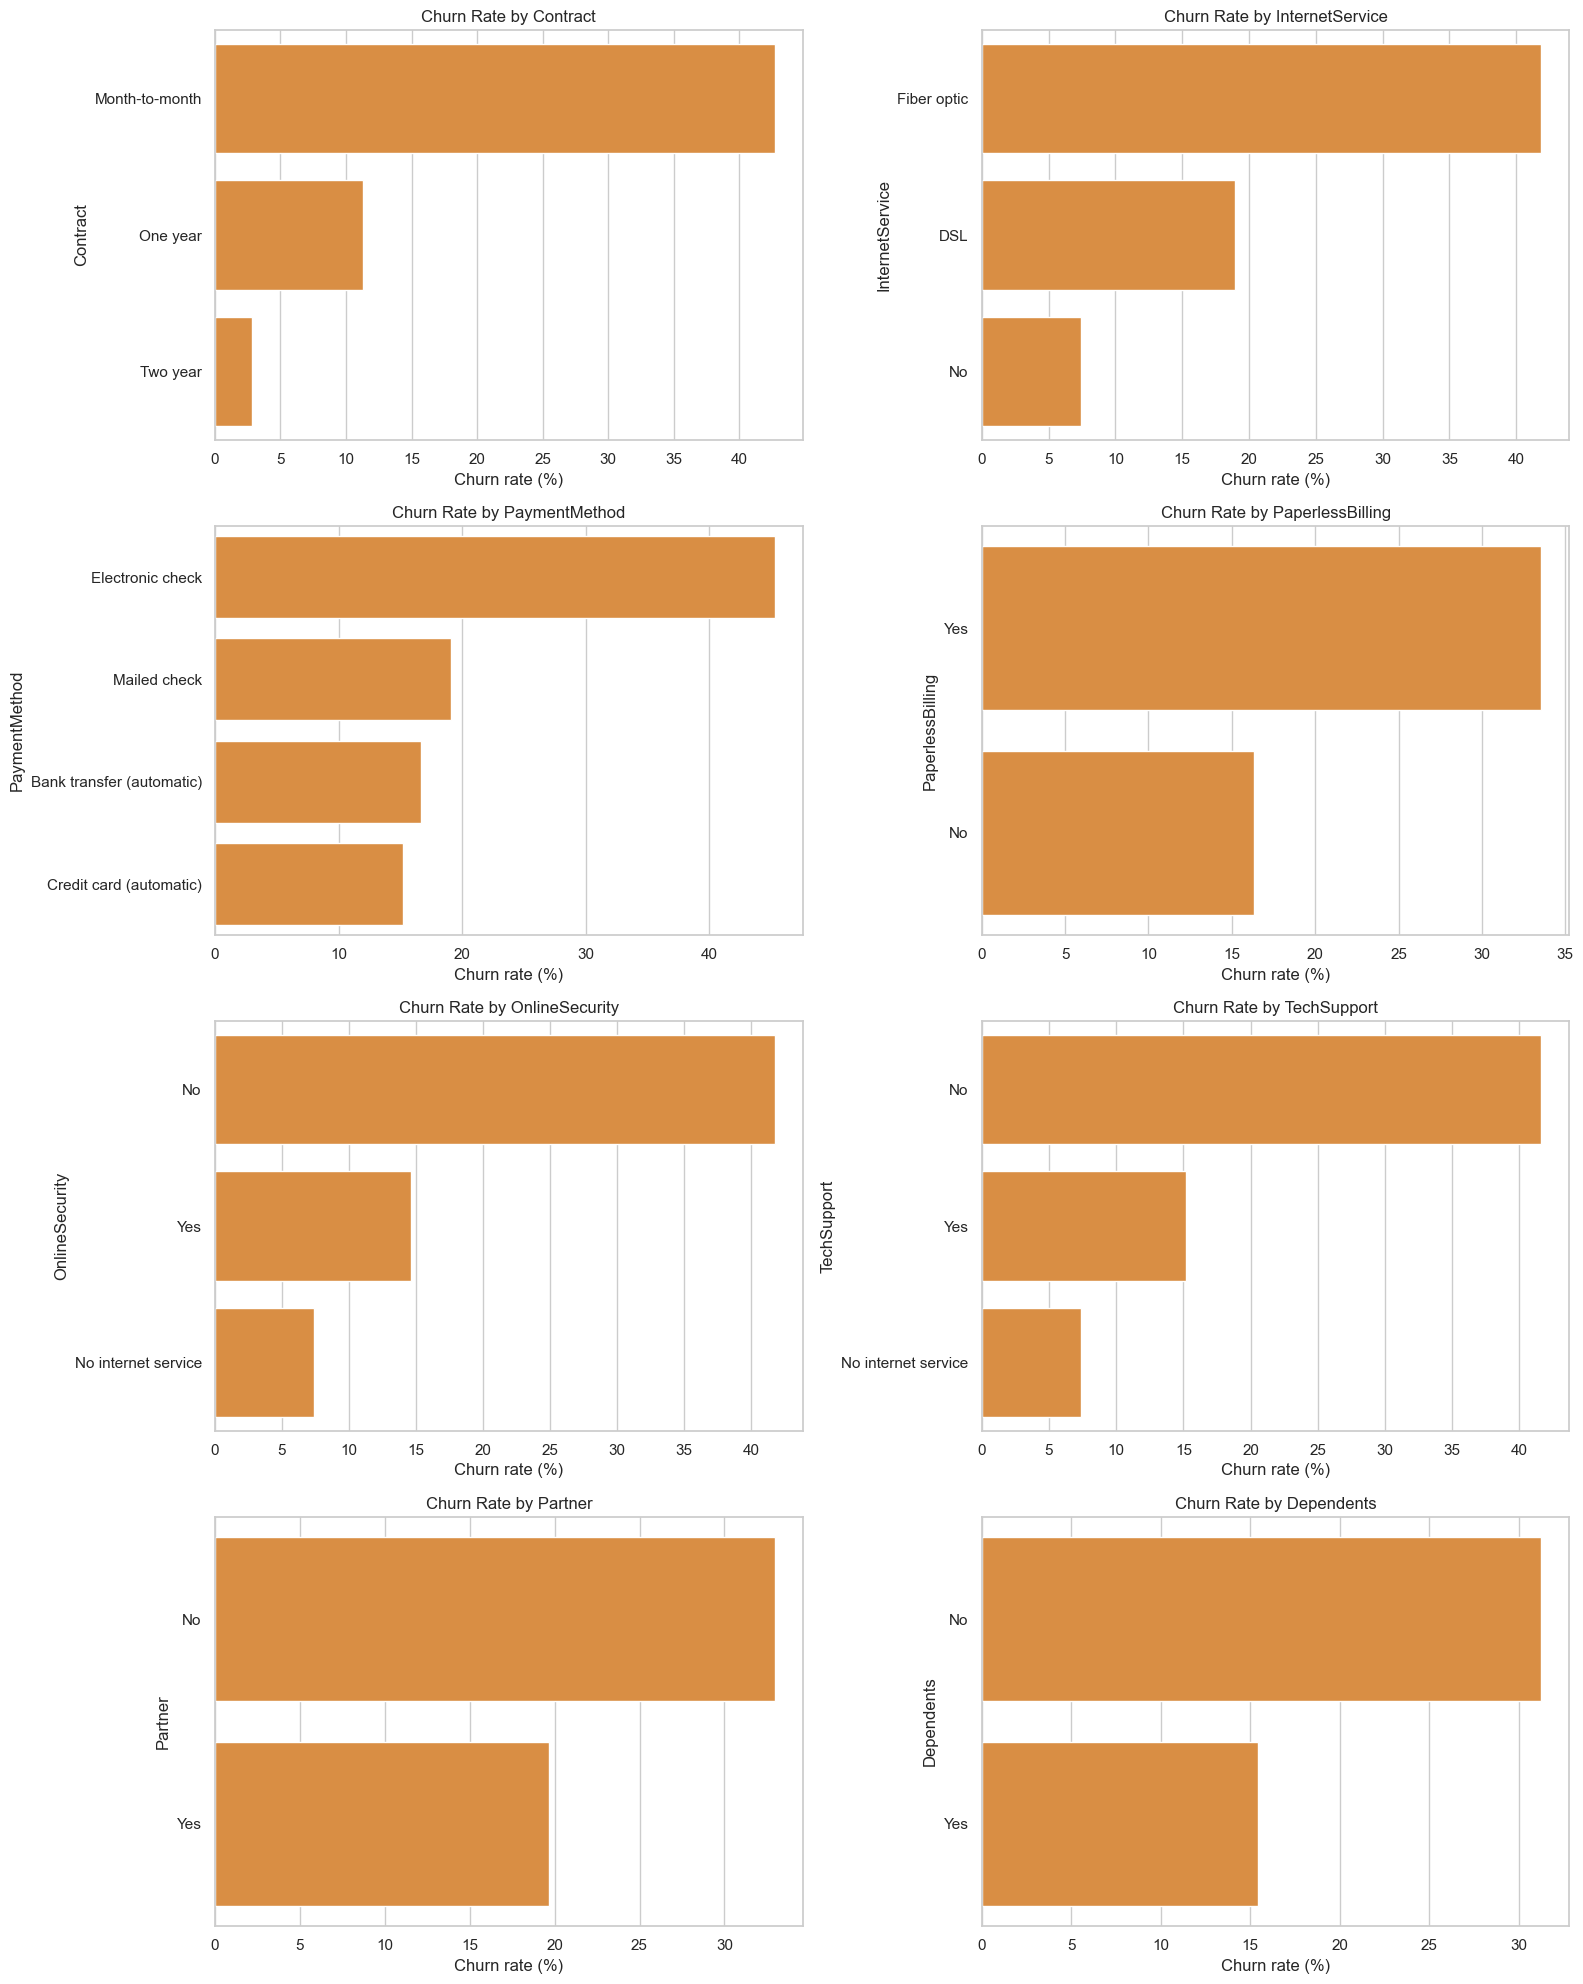

In [10]:
def churn_rate_table(data: pd.DataFrame, column: str) -> pd.DataFrame:
    summary = (
        data.groupby(column, dropna=False)["ChurnFlag"]
        .agg(churn_rate="mean", customers="size")
        .reset_index()
        .sort_values("churn_rate", ascending=False)
    )
    summary["churn_rate_pct"] = (summary["churn_rate"] * 100).round(2)
    summary = summary.rename(columns={column: "level"})
    summary["feature"] = column
    return summary[["feature", "level", "customers", "churn_rate_pct"]]


key_categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "OnlineSecurity",
    "TechSupport",
    "Partner",
    "Dependents",
]

categorical_summary = pd.concat(
    [churn_rate_table(df, feature) for feature in key_categorical_features],
    ignore_index=True,
)
display(categorical_summary.sort_values("churn_rate_pct", ascending=False).head(20))

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for ax, feature in zip(axes.flat, key_categorical_features):
    plot_data = churn_rate_table(df, feature)
    sns.barplot(data=plot_data, x="churn_rate_pct", y="level", color="#f28e2b", ax=ax)
    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel(feature)
plt.tight_layout()

### Интерпретация: категориальные признаки

Даже до моделирования видны несколько очень сильных бизнес-паттернов:

- **Month-to-month contracts** отваливаются заметно чаще, чем one-year и two-year контракты.
- У клиентов с **fiber optic** churn выше, чем у DSL-пользователей или клиентов без интернет-сервиса.
- Клиенты без **OnlineSecurity** или **TechSupport** уходят значительно чаще, что может отражать более слабую продуктовую stickiness или неудовлетворенные ожидания по сервису.
- У пользователей **electronic check** самый высокий churn среди способов оплаты, и **paperless billing** тоже связан с повышенным churn.
- Клиенты без **partners** или **dependents** тоже выглядят более склонными к уходу, что может говорить о связи между household stability и более низким риском оттока.

Для бизнеса эти находки ценны тем, что ведут к конкретным segment-specific действиям: contract design, onboarding, service bundling и targeted messaging можно выстраивать вокруг именно таких профилей.

In [11]:
candidate_categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

categorical_signal_strength = pd.DataFrame(
    {
        "feature": candidate_categorical_cols,
        "max_churn_gap_pp": [
            (
                df.groupby(feature, dropna=False)["ChurnFlag"].mean().max()
                - df.groupby(feature, dropna=False)["ChurnFlag"].mean().min()
            )
            * 100
            for feature in candidate_categorical_cols
        ],
    }
).sort_values("max_churn_gap_pp", ascending=False)

display(categorical_signal_strength.round(2))

,feature,max_churn_gap_pp
13,Contract,39.88
6,InternetService,34.49
7,OnlineSecurity,34.36
10,TechSupport,34.23
8,OnlineBackup,32.52
9,DeviceProtection,31.72
15,PaymentMethod,30.04
12,StreamingMovies,26.28
11,StreamingTV,26.12
1,SeniorCitizen,18.08


## 6. Резюме EDA

### Признаки, которые выглядят самыми важными до моделирования

Если опираться только на descriptive analysis, сильнейшими кандидатами в churn-драйверы выглядят:

- `Contract`, особенно разница между month-to-month и более длинными обязательствами
- `tenure`, особенно первый год жизни клиента
- `InternetService`, где у fiber optic клиентов заметно выше churn
- `OnlineSecurity` и `TechSupport`, отсутствие которых связано с более высоким churn
- `PaymentMethod`, особенно electronic check
- `PaperlessBilling`
- `MonthlyCharges`
- household stability proxies, такие как `Partner` и `Dependents`

### Риски в данных

- **Умеренный class imbalance** означает, что одной accuracy будет недостаточно для сравнения моделей.
- **Скрытые пропуски** в `TotalCharges` могут привести к тихим ошибкам, если пропустить явную очистку.
- **Риск identifier leakage** возникает, если по ошибке оставить `customerID` в моделировании.
- **Коррелированные сервисные признаки**, такие как online security, backup, device protection и tech support, могут создавать избыточность, особенно для линейных моделей.
- **Tenure и total charges механически связаны**, поэтому позже эффекты нужно будет интерпретировать аккуратно.
- Это **observational dataset**, поэтому сильные связи не стоит автоматически трактовать как причинные эффекты.

На этом этапе данные уже достаточно чистые, чтобы перейти к следующему шагу: feature preparation, train/test split, baseline setup и model training.

## 7. Генерация признаков

In [12]:
modeling_df = prepare_modeling_table(df)
engineered_feature_cols = [
    "tenure_group",
    "is_new_customer",
    "num_services",
    "avg_monthly_spend_proxy",
    "has_auto_payment",
]

display(modeling_df[engineered_feature_cols].head(10))

engineered_feature_summary = pd.DataFrame(
    {
        "feature": engineered_feature_cols,
        "dtype": [str(modeling_df[col].dtype) for col in engineered_feature_cols],
        "n_unique": [modeling_df[col].nunique(dropna=False) for col in engineered_feature_cols],
    }
)
display(engineered_feature_summary)
modeling_df[engineered_feature_cols].describe(include="all").T

,tenure_group,is_new_customer,num_services,avg_monthly_spend_proxy,has_auto_payment
0,0-12 months,Yes,2,29.85,No
1,25-48 months,No,4,55.57,No
2,0-12 months,Yes,4,54.08,No
3,25-48 months,No,4,40.91,Yes
4,0-12 months,Yes,2,75.83,No
5,0-12 months,Yes,6,102.56,No
6,13-24 months,No,5,88.61,Yes
7,0-12 months,Yes,2,30.19,No
8,25-48 months,No,7,108.79,No
9,49-72 months,No,4,56.26,Yes


,feature,dtype,n_unique
0,tenure_group,category,4
1,is_new_customer,str,2
2,num_services,int64,9
3,avg_monthly_spend_proxy,float64,6588
4,has_auto_payment,str,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure_group,7043,4,49-72 months,2239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_new_customer,7043,2,No,4857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_services,"7,043.00",NaN,NaN,NaN,4.15,2.31,1.00,2.00,4.00,6.00,9.00
avg_monthly_spend_proxy,"7,043.00",NaN,NaN,NaN,64.76,30.19,13.78,35.94,70.34,90.17,121.40
has_auto_payment,7043,2,No,3977,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Интерпретация: почему выбраны именно эти engineered features

Эти engineered features намеренно сделаны легкими и понятными для бизнеса:

- `tenure_group` отражает нелинейный churn-паттерн из EDA, особенно повышенный риск в первый год.
- `is_new_customer` превращает гипотезу про early-life retention в прямо используемый флаг.
- `num_services` приближенно отражает глубину использования продукта и bundle stickiness.
- `avg_monthly_spend_proxy` дополняет текущий monthly charge простым lifetime-spend взглядом.
- `has_auto_payment` сжимает платежное поведение в устойчивый бинарный сигнал, который легко операционализировать.

Ни один из этих признаков не использует будущее или сам target, поэтому они безопасны с точки зрения leakage, если preprocessing fit-ится только на training data.

## 8. Разбиение на train/test

In [13]:
X, y = split_features_target(modeling_df, target_column="ChurnFlag")
feature_groups = infer_feature_groups(X)
X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "share_pct": [round(len(X_train) / len(X) * 100, 2), round(len(X_test) / len(X) * 100, 2)],
        "churn_rate_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    }
)

display(split_summary)
display(
    pd.DataFrame(
        {
            "group": ["numeric", "categorical"],
            "count": [len(feature_groups["numeric"]), len(feature_groups["categorical"])],
            "features": [
                ", ".join(feature_groups["numeric"]),
                ", ".join(feature_groups["categorical"]),
            ],
        }
    )
)

,split,rows,share_pct,churn_rate_pct
0,train,5634,79.99,26.54
1,test,1409,20.01,26.54


,group,count,features
0,numeric,5,"tenure, MonthlyCharges, TotalCharges, num_serv..."
1,categorical,19,"gender, SeniorCitizen, Partner, Dependents, Ph..."


### Интерпретация: почему важен stratified split

Мы используем stratified train/test split, чтобы сохранить churn rate в обеих выборках. Это важно, потому что target несбалансирован, и мы хотим, чтобы model evaluation отражал тот же target mix, что и training data.

Target отделяется до model fitting, а preprocessing transformer fit-ится только на `X_train`. Это предотвращает leakage через частоты категорий в test set, параметры scaling или импутации.

## 9. Пайплайн preprocessing

In [14]:
logreg_preprocessor = build_preprocessor(
    feature_groups=feature_groups,
    scale_numeric=True,
    one_hot_drop="if_binary",
)
tree_preprocessor = build_preprocessor(
    feature_groups=feature_groups,
    scale_numeric=False,
    one_hot_drop=None,
)

X_train_prepared = logreg_preprocessor.fit_transform(X_train)
X_test_prepared = logreg_preprocessor.transform(X_test)
transformed_feature_names = get_transformed_feature_names(logreg_preprocessor)

print(f"Logistic Regression train matrix shape: {X_train_prepared.shape}")
print(f"Logistic Regression test matrix shape: {X_test_prepared.shape}")
print(f"Final transformed feature count: {len(transformed_feature_names)}")

display(pd.Series(transformed_feature_names, name="transformed_feature").to_frame().head(30))

Logistic Regression train matrix shape: (5634, 48)
Logistic Regression test matrix shape: (1409, 48)
Final transformed feature count: 48


,transformed_feature
0,tenure
1,MonthlyCharges
2,TotalCharges
3,num_services
4,avg_monthly_spend_proxy
5,gender_Male
6,SeniorCitizen_Yes
7,Partner_Yes
8,Dependents_Yes
9,PhoneService_Yes


### Интерпретация: решения по preprocessing

Стратегия preprocessing намеренно строится с учетом особенностей моделей:

- **Numeric features** используют median imputation и standard scaling для Logistic Regression, потому что линейные модели чувствительны к масштабу признаков.
- **Categorical features** используют most-frequent imputation и one-hot encoding с `handle_unknown='ignore'`, чтобы inference оставался устойчивым даже при появлении unseen categories.
- Для Logistic Regression мы применяем `drop='if_binary'`, чтобы сократить избыточные бинарные dummy columns и при этом сохранить интерпретируемость.
- Отдельно создается tree-oriented preprocessor без numeric scaling, потому что Random Forest в нем не нуждается.

Такой setup делает workflow воспроизводимым, позволяет честно сравнивать модели и не допускает leakage, потому что все transformers fit-ятся только на training data.

## 10. Резюме этапа

К концу preprocessing-этапа у нас есть:

- очищенная modeling table с raw и engineered features;
- leakage-safe split на train и test с сохранением churn ratio;
- четко разделенные numeric и categorical feature groups;
- preprocessing pipeline для Logistic Regression со scaling и one-hot encoding;
- tree-ready вариант preprocessing для последующего Random Forest modeling.

Следующий раздел использует эти артефакты для baseline definition, обучения моделей, сравнения метрик, ROC analysis и продуктовой интерпретации false positives и false negatives.

## 11. Моделирование

In [15]:
model_preprocessors = {
    "logistic_regression": logreg_preprocessor,
    "random_forest": tree_preprocessor,
}
models = train_all_models(X_train, y_train, model_preprocessors)
model_order = ["Baseline", "Logistic Regression", "Random Forest"]
list(models.keys())

['Baseline', 'Logistic Regression', 'Random Forest']

### Настройка моделирования

Мы сравниваем три модели:

- **Baseline**: dummy classifier, который предсказывает поведение большинства и задает минимальный benchmark.
- **Logistic Regression**: сильный линейный baseline с аккуратно масштабированными numeric variables и one-hot encoded категориями.
- **Random Forest**: нелинейный ансамбль, который умеет захватывать interaction effects и более гибкие decision boundaries.

Для portfolio-проекта такое сочетание полезно тем, что показывает и дисциплину в baseline-thinking, и содержательное сравнение между интерпретируемой линейной моделью и более сильной tree-based альтернативой.

## 12. Оценка моделей

In [16]:
metrics_table = build_metrics_table(models, X_test, y_test)
metrics_table["model"] = pd.Categorical(metrics_table["model"], categories=model_order, ordered=True)
metrics_table = metrics_table.sort_values("model").reset_index(drop=True)

metrics_display = metrics_table.copy()
for metric in ["accuracy", "precision", "recall", "roc_auc"]:
    metrics_display[metric] = metrics_display[metric].round(4)
for count_col in ["tn", "fp", "fn", "tp"]:
    metrics_display[count_col] = metrics_display[count_col].astype(int)

display(metrics_display)

,model,accuracy,precision,recall,roc_auc,tn,fp,fn,tp
0,Baseline,0.73,0.00,0.00,0.50,1035,0,374,0
1,Logistic Regression,0.73,0.50,0.79,0.84,736,299,78,296
2,Random Forest,0.77,0.56,0.73,0.84,817,218,102,272


### Интерпретация: что означают метрики в churn-заче

- **Accuracy** — это доля всех клиентов, классифицированных правильно. Для churn prediction метрика полезна, но опасно переоценивать ее значимость из-за class imbalance.
- **Precision** отвечает на вопрос: среди клиентов, которых модель пометила как потенциально уходящих, сколько действительно уйдут? Низкий precision означает перерасход retention-бюджета.
- **Recall** отвечает на вопрос: среди клиентов, которые действительно уйдут, скольких мы успели поймать? Низкий recall означает предотвратимые потери выручки.
- **ROC-AUC** измеряет качество ранжирования по всем threshold. Это важно, потому что реальные retention-программы часто подбирают decision threshold под бюджет и емкость кампаний.

Baseline model здесь особенно важна: она показывает внешне неплохую accuracy просто потому, что предсказывает, что все останутся, но при этом ее recall равен нулю. Это классический пример того, почему одной accuracy для churn недостаточно.

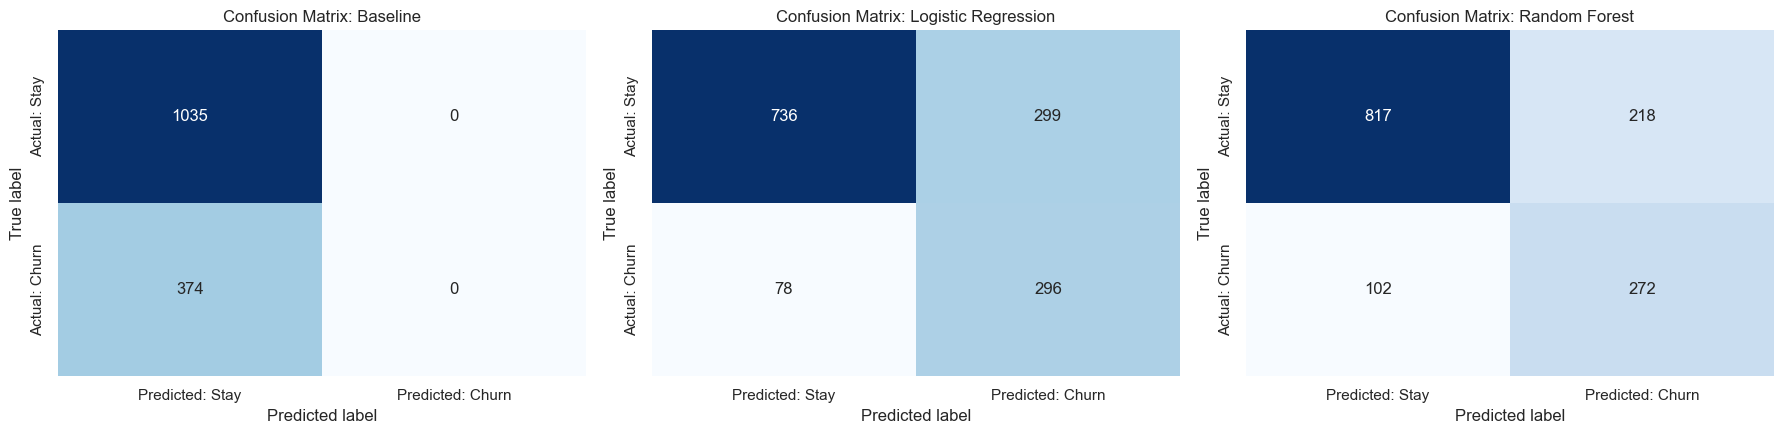

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, model_name in zip(axes, model_order):
    cm_df = get_confusion_matrix_frame(models[model_name], X_test, y_test)
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix: {model_name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()

### Интерпретация: confusion matrices

Confusion matrices делают product trade-off наглядным:

- **Baseline** пропускает всех churn-клиентов, то есть оставляет бизнес слепым к предотвратимым потерям выручки.
- **Logistic Regression** ловит больше churn-клиентов и поэтому лучше соответствует aggressive retention-подходу.
- **Random Forest** дает меньше ложных тревог, что полезно, если incentives дорогие или емкость кампаний ограничена.

Если говорить на языке бизнеса, false negatives — это упущенные сохранения клиента, а false positives — лишние retention-контакты. Что из этого больнее, зависит от стоимости кампании и customer lifetime value.

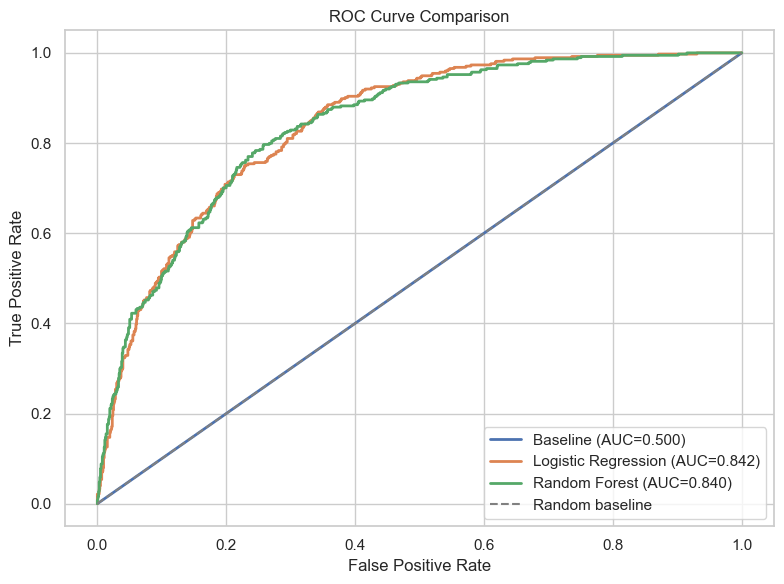

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for model_name in model_order:
    roc_df = get_roc_curve_data(models[model_name], X_test, y_test)
    model_auc = metrics_table.loc[metrics_table["model"] == model_name, "roc_auc"].iloc[0]
    ax.plot(roc_df["fpr"], roc_df["tpr"], linewidth=2, label=f"{model_name} (AUC={model_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()

### Интерпретация: ROC curve

ROC-AUC полезна здесь именно потому, что финальный threshold — это в итоге бизнес-решение, а не только modeling-решение. Модель с более сильным качеством ранжирования дает retention-команде больше гибкости: бизнес позже может ужесточать или ослаблять threshold в зависимости от бюджета, емкости канала или цели кампании.

В этом проекте и Logistic Regression, и Random Forest отделяют churn-клиентов от non-churn заметно лучше baseline, но у Logistic Regression есть небольшое преимущество по ROC-AUC.

## 13. Trade-off между precision и recall

Для churn-retention precision-recall trade-off напрямую связан с экономикой кампаний:

- **Более высокий recall** означает, что мы ловим больше клиентов, которые действительно находятся в риске. Это снижает число false negatives и, следовательно, уменьшает предотвратимые потери выручки.
- **Более высокий precision** означает, что мы реже ошибочно таргетируем клиентов. Это уменьшает лишние скидки, нагрузку на поддержку и campaign fatigue.

В наших результатах у Logistic Regression выше recall, а у Random Forest — выше precision. С продуктовой точки зрения это означает:

- выбирать **Logistic Regression**, когда стоимость пропущенного churn-клиента выше, чем стоимость дополнительного retention-touch;
- выбирать **Random Forest**, когда retention-actions дороги и команде нужен более узкий и более уверенный список клиентов.

Поскольку churn умеренно несбалансирован, этот trade-off важнее, чем сырая accuracy. Бизнесу не стоит вознаграждать модель за консервативность, если эта консервативность просто скрывает клиентов в зоне риска.

## 14. Выбор лучшей модели

### Выбранная модель: Logistic Regression

Для этого churn use case лучшим выбором является Logistic Regression.

Технические причины:

- У нее самый высокий **ROC-AUC**, то есть немного лучшее качество ранжирования в целом.
- У нее самый высокий **recall**, а значит она ловит больше реальных churn-клиентов, чем Random Forest.
- Она уверенно обыгрывает dummy baseline, что подтверждает: модель действительно учится на meaningful churn structure, а не просто эксплуатирует class imbalance.

Продуктовые причины:

- Бизнес-цель здесь — proactive retention, а значит пропустить churn-клиента обычно дороже, чем отправить один дополнительный retention-offer.
- По сравнению с Random Forest, Logistic Regression находит больше at-risk клиентов, и это часто оказывается лучшим trade-off, когда компания хочет защищать выручку и LTV.
- Линейная структура модели еще и проще объясняется продуктовым и маркетинговым стейкхолдерам, что повышает доверие и actionability.

При этом Random Forest остается сильной альтернативой на случай, если позже retention-программа станет более budget-constrained, а precision станет доминирующей целью.

## 15. Интерпретация моделей

In [19]:
logreg_feature_names = models["Logistic Regression"].named_steps["preprocessor"].get_feature_names_out().tolist()
rf_feature_names = models["Random Forest"].named_steps["preprocessor"].get_feature_names_out().tolist()

logreg_coefficients = summarize_feature_importance(models["Logistic Regression"], logreg_feature_names)
rf_importance = summarize_feature_importance(models["Random Forest"], rf_feature_names)

logreg_positive = logreg_coefficients.sort_values("importance", ascending=False).head(12).reset_index(drop=True)
logreg_negative = logreg_coefficients.sort_values("importance", ascending=True).head(12).reset_index(drop=True)
rf_top_features = rf_importance.head(15).reset_index(drop=True)

logreg_family_importance = aggregate_importance_by_feature_family(logreg_coefficients, X.columns.tolist())
rf_family_importance = aggregate_importance_by_feature_family(rf_importance, X.columns.tolist())

display(logreg_positive.round(4))
display(logreg_negative.round(4))
display(rf_top_features.round(4))
display(logreg_family_importance.head(12).round(4))
display(rf_family_importance.head(12).round(4))

,feature,importance,abs_importance
0,Contract_Month-to-month,0.68,0.68
1,InternetService_Fiber optic,0.68,0.68
2,PaperlessBilling_Yes,0.35,0.35
3,num_services,0.33,0.33
4,tenure_group_49-72 months,0.32,0.32
5,OnlineSecurity_No,0.21,0.21
6,TotalCharges,0.19,0.19
7,TechSupport_No,0.18,0.18
8,StreamingMovies_Yes,0.17,0.17
9,SeniorCitizen_Yes,0.16,0.16


,feature,importance,abs_importance
0,tenure,-1.03,1.03
1,Contract_Two year,-0.87,0.87
2,InternetService_DSL,-0.68,0.68
3,MonthlyCharges,-0.63,0.63
4,tenure_group_13-24 months,-0.39,0.39
5,DeviceProtection_No internet service,-0.24,0.24
6,InternetService_No,-0.24,0.24
7,StreamingMovies_No internet service,-0.24,0.24
8,OnlineBackup_No internet service,-0.24,0.24
9,TechSupport_No internet service,-0.24,0.24


,feature,importance,abs_importance
0,Contract_Month-to-month,0.10,0.10
1,tenure,0.10,0.10
2,TotalCharges,0.07,0.07
3,avg_monthly_spend_proxy,0.07,0.07
4,MonthlyCharges,0.06,0.06
5,OnlineSecurity_No,0.05,0.05
6,Contract_Two year,0.05,0.05
7,TechSupport_No,0.04,0.04
8,InternetService_Fiber optic,0.04,0.04
9,is_new_customer_Yes,0.03,0.03


,feature_family,total_abs_importance,mean_signed_importance,transformed_features
0,Contract,1.61,-0.08,3
1,InternetService,1.59,-0.08,3
2,tenure,1.03,-1.03,1
3,tenure_group,0.90,-0.06,4
4,OnlineSecurity,0.67,-0.08,3
5,MonthlyCharges,0.63,-0.63,1
6,TechSupport,0.60,-0.08,3
7,StreamingMovies,0.59,-0.08,3
8,StreamingTV,0.56,-0.08,3
9,PaymentMethod,0.52,-0.06,4


,feature_family,total_abs_importance,mean_signed_importance,transformed_features
0,Contract,0.16,0.05,3
1,tenure,0.10,0.10,1
2,TotalCharges,0.07,0.07,1
3,OnlineSecurity,0.07,0.02,3
4,avg_monthly_spend_proxy,0.07,0.07,1
5,InternetService,0.06,0.02,3
6,MonthlyCharges,0.06,0.06,1
7,TechSupport,0.06,0.02,3
8,tenure_group,0.05,0.01,4
9,is_new_customer,0.05,0.02,2


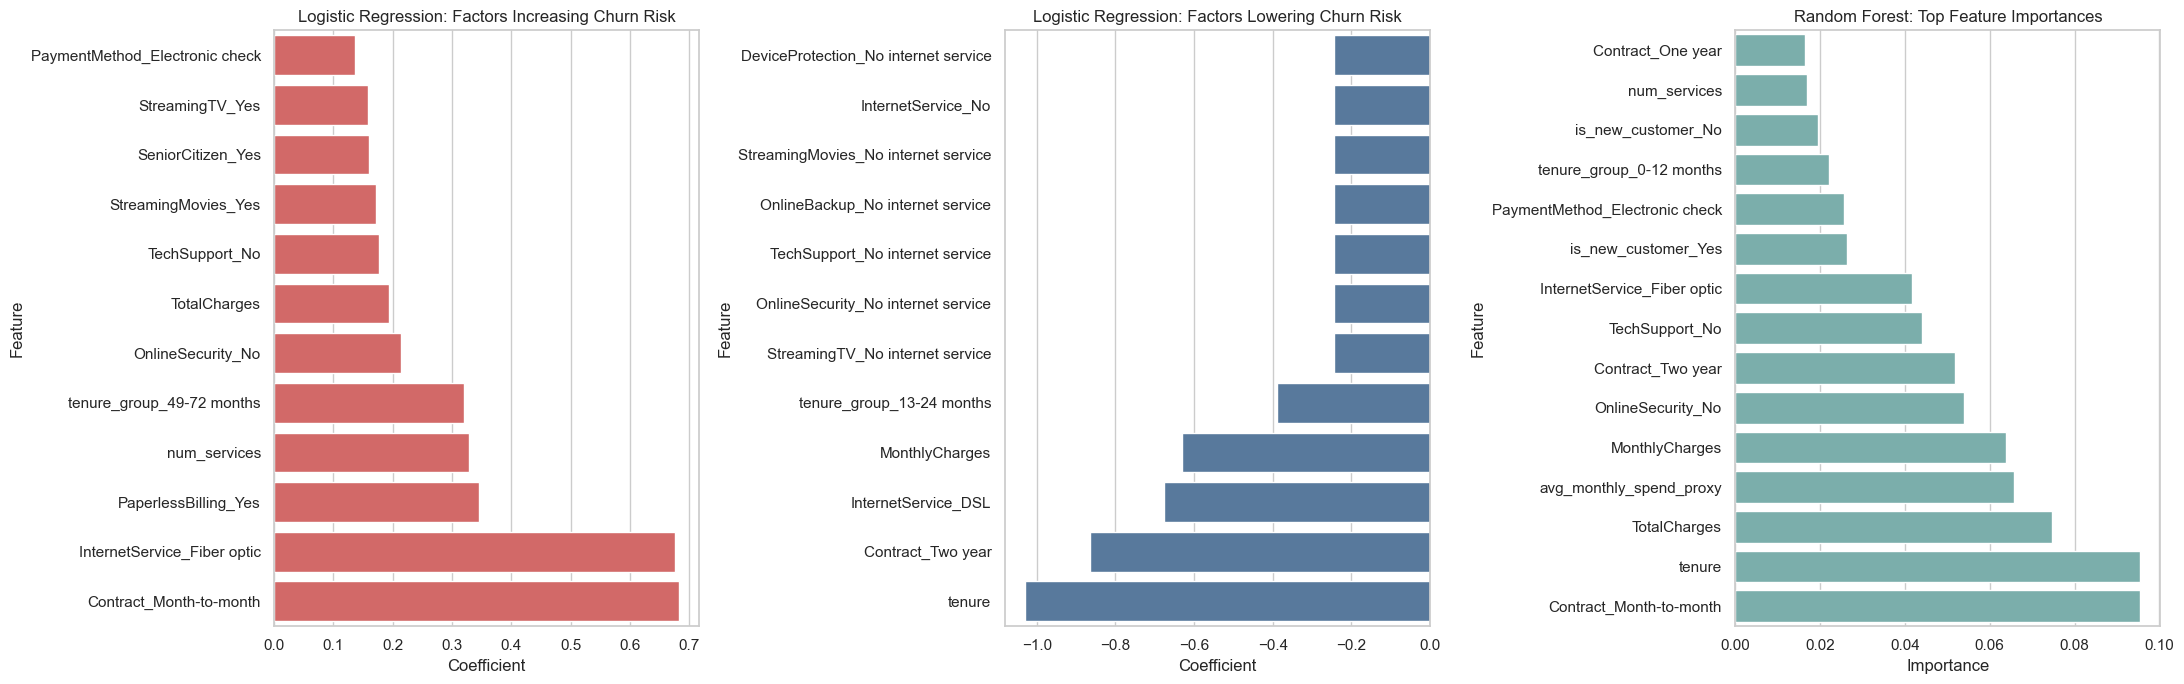

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

sns.barplot(
    data=logreg_positive.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    color="#e45756",
    ax=axes[0],
)
axes[0].set_title("Logistic Regression: Factors Increasing Churn Risk")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Feature")

sns.barplot(
    data=logreg_negative.sort_values("importance", ascending=False),
    x="importance",
    y="feature",
    color="#4c78a8",
    ax=axes[1],
)
axes[1].set_title("Logistic Regression: Factors Lowering Churn Risk")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("Feature")

sns.barplot(
    data=rf_top_features.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    color="#72b7b2",
    ax=axes[2],
)
axes[2].set_title("Random Forest: Top Feature Importances")
axes[2].set_xlabel("Importance")
axes[2].set_ylabel("Feature")

plt.tight_layout()

### Как аккуратно читать коэффициенты

Коэффициенты Logistic Regression нужно интерпретировать как направленные сигналы, а не как самостоятельные causal effects. Поскольку мы используем one-hot encoding, каждый категориальный коэффициент читается относительно скрытой reference category. Кроме того, часть engineered features намеренно связана с уже существующими переменными, например `tenure` и `tenure_group`, поэтому точные знаки коэффициентов могут частично отражать общий сигнал внутри коррелированных признаков.

Именно поэтому мы комбинируем три оптики:

- raw coefficients из Logistic Regression,
- нелинейную feature importance из Random Forest,
- descriptive EDA patterns и профилирование risk-сегментов.

Когда одна и та же история повторяется во всех трех слоях, о ней можно говорить значительно увереннее.

### Logistic Regression: что повышает и что снижает риск

Самые сильные churn-increasing сигналы в Logistic Regression складываются в очень понятную историю:

- **Month-to-month contracts** резко повышают churn-risk. Бизнес-гипотеза: у таких клиентов низкий switching friction, а само обязательство перед компанией еще недостаточно сильное, чтобы пережить раннее разочарование.
- Клиенты с **fiber optic** выглядят рискованнее, чем DSL-пользователи или клиенты без интернет-сервиса. Бизнес-гипотеза: это может быть premium-сегмент с более высокими счетами и более высокими ожиданиями к качеству, поэтому разочарование здесь дороже и заметнее.
- **Paperless billing** и **electronic check** тяготеют к более высокому churn. Бизнес-гипотеза: такие клиенты взаимодействуют с компанией в более легком и менее привязанном формате, и их проще потерять, если не подкреплять ощущение ценности.
- Клиенты без **online security** или **tech support** стабильно выглядят более хрупкими. Бизнес-гипотеза: либо они недоиспользуют sticky value-added features, либо уже живут с нерешенными сервисными проблемами.
- У **senior customers** тоже заметен повышенный риск в линейной модели. Бизнес-гипотеза: это может указывать на более высокую чувствительность к сервисному friction и потребность в guided support вместо чистого self-serve.

Самые сильные churn-reducing факторы тоже хорошо переводятся в бизнес-язык:

- **Длинный tenure** остается одним из самых очевидных защитных сигналов. Если клиент переживает ранний lifecycle, потерять его становится значительно сложнее.
- **Two-year contracts** сильно снижают churn-risk. Бизнес-гипотеза: commitment mechanisms и perceived switching cost действительно работают.
- **Online security**, **tech support** и **automatic payment** связаны с более низким churn. Бизнес-гипотеза: эти features повышают привычку, perceived value и общую операционную гладкость сервиса.
- **Dependents** ассоциированы с более низким churn. Бизнес-гипотеза: многопользовательская household-зависимость делает аккаунт стабильнее и менее склонным к случайной замене.

### Random Forest: что важно для нелинейной модели

Random Forest подтверждает ту же самую историю, но под другим углом. Среди его top factors — `Contract`, `tenure`, `TotalCharges`, `avg_monthly_spend_proxy`, `MonthlyCharges`, `OnlineSecurity`, `TechSupport`, `InternetService` и `PaymentMethod`.

Это важно, потому что tree-модель свободно улавливает interactions. Простыми словами, churn здесь не объясняется одной изолированной проблемой. Чаще всего это сочетание:

- слабой структуры обязательств перед компанией,
- короткого customer lifetime,
- более высоких регулярных расходов,
- и слабой привязанности к support/security services.

Для product и marketing это полезное подтверждение: риск носит структурный, а не случайный характер. Мы видим узнаваемые клиентские ситуации, под которые можно проектировать разные interventions.

In [21]:
scored_test = X_test.copy()
scored_test["actual_churn"] = y_test.to_numpy()
scored_test["churn_score"] = get_prediction_scores(models["Logistic Regression"], X_test)
scored_test["risk_segment"] = assign_risk_segments(
    pd.Series(scored_test["churn_score"]),
    low_threshold=0.3,
    high_threshold=0.6,
)

risk_segment_summary = (
    scored_test.groupby("risk_segment", observed=False)
    .agg(
        customers=("actual_churn", "size"),
        actual_churn_rate=("actual_churn", "mean"),
        avg_model_score=("churn_score", "mean"),
    )
    .reset_index()
)
risk_segment_summary[["actual_churn_rate", "avg_model_score"]] = risk_segment_summary[["actual_churn_rate", "avg_model_score"]].round(3)

high_risk = scored_test.loc[scored_test["risk_segment"] == "High risk"].copy()
high_risk_profile = pd.DataFrame(
    {
        "signal": [
            "Month-to-month contract",
            "Fiber optic internet",
            "Electronic check",
            "No online security",
            "No tech support",
            "Tenure <= 12 months",
            "No auto payment",
        ],
        "high_risk_customers": [
            int((high_risk["Contract"] == "Month-to-month").sum()),
            int((high_risk["InternetService"] == "Fiber optic").sum()),
            int((high_risk["PaymentMethod"] == "Electronic check").sum()),
            int((high_risk["OnlineSecurity"] == "No").sum()),
            int((high_risk["TechSupport"] == "No").sum()),
            int((high_risk["tenure"] <= 12).sum()),
            int((high_risk["has_auto_payment"] == "No").sum()),
        ],
    }
)
high_risk_profile["share_of_high_risk_pct"] = (high_risk_profile["high_risk_customers"] / len(high_risk) * 100).round(1)

priority_segment_table = pd.DataFrame(
    {
        "segment": [
            "Price-sensitive newcomers",
            "Service-gap customers",
            "Payment-friction customers",
        ],
        "definition": [
            "Month-to-month + tenure <= 12 months + fiber optic",
            "No online security + no tech support + internet customer",
            "Electronic check + no auto payment",
        ],
        "customers_in_test": [
            int(((scored_test["Contract"] == "Month-to-month") & (scored_test["tenure"] <= 12) & (scored_test["InternetService"] == "Fiber optic")).sum()),
            int(((scored_test["OnlineSecurity"] == "No") & (scored_test["TechSupport"] == "No") & (scored_test["InternetService"] != "No")).sum()),
            int(((scored_test["PaymentMethod"] == "Electronic check") & (scored_test["has_auto_payment"] == "No")).sum()),
        ],
        "actual_churn_rate": [
            round(scored_test.loc[(scored_test["Contract"] == "Month-to-month") & (scored_test["tenure"] <= 12) & (scored_test["InternetService"] == "Fiber optic"), "actual_churn"].mean(), 3),
            round(scored_test.loc[(scored_test["OnlineSecurity"] == "No") & (scored_test["TechSupport"] == "No") & (scored_test["InternetService"] != "No"), "actual_churn"].mean(), 3),
            round(scored_test.loc[(scored_test["PaymentMethod"] == "Electronic check") & (scored_test["has_auto_payment"] == "No"), "actual_churn"].mean(), 3),
        ],
        "avg_model_score": [
            round(scored_test.loc[(scored_test["Contract"] == "Month-to-month") & (scored_test["tenure"] <= 12) & (scored_test["InternetService"] == "Fiber optic"), "churn_score"].mean(), 3),
            round(scored_test.loc[(scored_test["OnlineSecurity"] == "No") & (scored_test["TechSupport"] == "No") & (scored_test["InternetService"] != "No"), "churn_score"].mean(), 3),
            round(scored_test.loc[(scored_test["PaymentMethod"] == "Electronic check") & (scored_test["has_auto_payment"] == "No"), "churn_score"].mean(), 3),
        ],
    }
)

display(risk_segment_summary)
display(high_risk_profile)
display(priority_segment_table)

,risk_segment,customers,actual_churn_rate,avg_model_score
0,Low risk,599,0.05,0.11
1,Medium risk,331,0.24,0.45
2,High risk,479,0.56,0.77


,signal,high_risk_customers,share_of_high_risk_pct
0,Month-to-month contract,466,97.30
1,Fiber optic internet,377,78.70
2,Electronic check,309,64.50
3,No online security,428,89.40
4,No tech support,418,87.30
5,Tenure <= 12 months,280,58.50
6,No auto payment,373,77.90


,segment,definition,customers_in_test,actual_churn_rate,avg_model_score
0,Price-sensitive newcomers,Month-to-month + tenure <= 12 months + fiber o...,186,0.66,0.86
1,Service-gap customers,No online security + no tech support + interne...,519,0.48,0.68
2,Payment-friction customers,Electronic check + no auto payment,474,0.43,0.64


### Какие клиенты выглядят самыми рискованными

High-risk сегмент у лучшей модели — это не случайный шум. Он концентрируется в очень узнаваемом клиентском профиле:

- в основном это **month-to-month** клиенты,
- среди них сильно смещена доля пользователей **fiber optic**,
- заметно чаще встречаются клиенты с **electronic check**,
- и доминируют люди без **online security** и **tech support**.

Самый тревожный паттерн — кластер "price-sensitive newcomer": month-to-month fiber-клиенты в первый год жизни. На нашем test sample у этого сегмента особенно высокий realized churn rate, а значит проблема, вероятно, одновременно связана с качеством onboarding, восприятием первых счетов и общей ценностью продукта.

Второй важный сегмент — это "service-gap" клиент: он уже платит за интернет, но не привязан к security и support-продуктам. Это очень похоже на классическую проблему value perception. Компания продает доступ, но не встраивает клиента в более широкую сервисную экосистему.

Третий сегмент — это "payment-friction" клиент: пользователи electronic check без auto payment. Для них, скорее всего, нужны interventions вокруг billing-experience, а не просто широкие скидки.

### Кого таргетировать первым и как различать стратегии

Если retention-capacity ограничена, в первую волну стоит отправлять клиентов, которые одновременно сочетают **high model score** и **бизнес-ценность**, особенно если у них небольшой tenure, но уже заметные monthly charges.

Практический порядок таргетинга может быть таким:

1. **High-risk, first-year, month-to-month fiber customers**: здесь стоит вмешиваться быстро, потому что они одновременно уязвимы и еще вполне спасаемы на раннем этапе отношений.
2. **High-risk клиенты без adoption у security/support services**: для них лучше использовать service-led save mechanics, а не только скидки.
3. **High-risk electronic-check клиенты**: фокус на снижении payment friction и переводе в autopay.

При этом этим сегментам не стоит показывать один и тот же offer:

- **Price-sensitive newcomers** могут лучше реагировать на bill relief, contract-migration offers или first-90-days save playbook.
- **Service-gap customers** могут лучше откликаться на education, bundled support/security trials или proactive troubleshooting.
- **Payment-friction customers** могут вообще не нуждаться в скидке; им может быть достаточно более гладкого billing experience.

Именно на этом уровне churn modeling превращается в продуктовую систему, а не остается просто scoring exercise.

## 16. Бизнес-рекомендации

1. **В первую очередь таргетировать first-year month-to-month fiber customers через proactive outreach.** Это самый очевидный high-risk кластер, и ждать входящей жалобы здесь уже поздно.
2. **Тестировать contract-migration offers для рискованных month-to-month клиентов.** Небольшие credits, bundle upgrades или ограниченные по времени annual-plan incentives могут снижать switching behavior эффективнее, чем generic discounts.
3. **Предлагать bundle или trial для Online Security и Tech Support у хрупких internet-клиентов.** Эти features стабильно связаны с более низким churn и, вероятно, усиливают perceived stickiness.
4. **Запустить payment-friction кампанию для клиентов с electronic check.** Стимулировать переход в autopay через convenience messaging, billing reassurance и, возможно, разовый incentive.
5. **Построить early-life retention journey на первые 90-180 дней.** Фокус на качестве onboarding, expectation setting, понятности first bill и proactive service checks, чтобы не дать раннему churn укорениться.
6. **Использовать score-based retention tiers вместо one-size-fits-all кампаний.** High-risk клиенты заслуживают human outreach или сильных offers, medium-risk можно вести более легкими nudges, а low-risk лучше защищать от лишнего discounting.
7. **Проводить A/B tests по сегментам, а не только глобально.** Лучшее save action для price-sensitive newcomer почти наверняка будет отличаться от оптимального действия для service-gap или billing-friction клиента.

## 17. Подбор threshold

In [22]:
best_model_name = "Logistic Regression"
best_model = models[best_model_name]
best_model_scores = scored_test["churn_score"].to_numpy()

threshold_metrics = build_threshold_metrics_table(
    y_test,
    best_model_scores,
    thresholds=np.round(np.arange(0.10, 0.91, 0.05), 2),
)
threshold_metrics[["tn", "fp", "fn", "tp", "targeted_customers"]] = threshold_metrics[["tn", "fp", "fn", "tp", "targeted_customers"]].astype(int)

balanced_threshold_hint = find_optimal_threshold(y_test, best_model_scores, strategy="balanced")
display(threshold_metrics.round(4))
balanced_threshold_hint

,threshold,accuracy,precision,recall,tn,fp,fn,tp,targeted_customers,f1
0,0.10,0.49,0.34,0.99,322,713,4,370,1083,0.51
1,0.15,0.55,0.37,0.97,406,629,10,364,993,0.53
2,0.20,0.59,0.39,0.96,475,560,15,359,919,0.56
3,0.25,0.62,0.41,0.94,525,510,23,351,861,0.57
4,0.30,0.65,0.43,0.93,571,464,28,346,810,0.58
5,0.35,0.68,0.45,0.90,617,418,36,338,756,0.60
6,0.40,0.71,0.47,0.88,667,368,45,329,697,0.61
7,0.45,0.72,0.49,0.83,706,329,64,310,639,0.61
8,0.50,0.73,0.50,0.79,736,299,78,296,595,0.61
9,0.55,0.76,0.54,0.75,791,244,92,282,526,0.63


{'threshold': 0.5599999999999999,
 'accuracy': 0.7650816181689141,
 'precision': 0.5415860735009671,
 'recall': 0.7486631016042781,
 'tn': 798.0,
 'fp': 237.0,
 'fn': 94.0,
 'tp': 280.0,
 'targeted_customers': 517.0,
 'f1': 0.6285072951739619,
 'balanced_score': 1.2902491751052452}

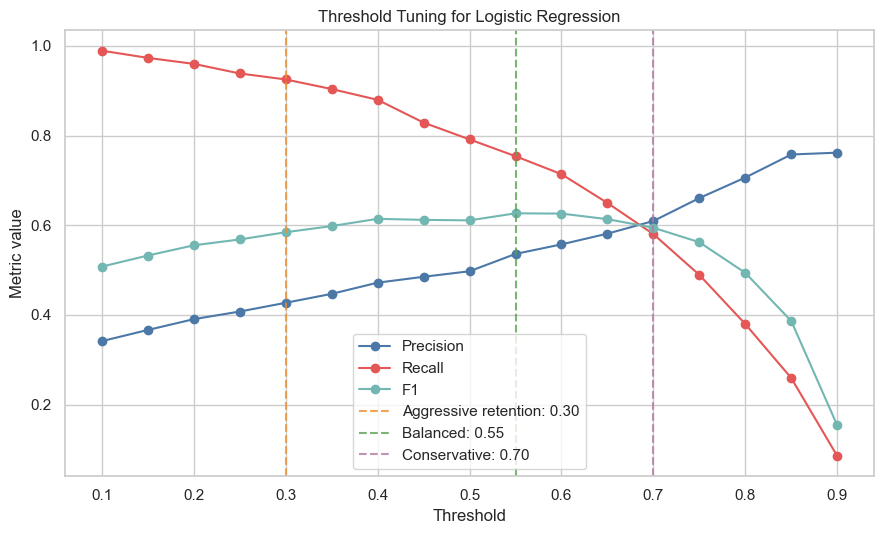

In [23]:
scenario_thresholds = {
    "Aggressive retention": 0.30,
    "Balanced": 0.55,
    "Conservative": 0.70,
}

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(threshold_metrics["threshold"], threshold_metrics["precision"], marker="o", label="Precision", color="#4c78a8")
ax.plot(threshold_metrics["threshold"], threshold_metrics["recall"], marker="o", label="Recall", color="#e45756")
ax.plot(threshold_metrics["threshold"], threshold_metrics["f1"], marker="o", label="F1", color="#72b7b2")

scenario_colors = {
    "Aggressive retention": "#f28e2b",
    "Balanced": "#59a14f",
    "Conservative": "#b07aa1",
}
for scenario_name, threshold in scenario_thresholds.items():
    ax.axvline(threshold, linestyle="--", color=scenario_colors[scenario_name], alpha=0.8, label=f"{scenario_name}: {threshold:.2f}")

ax.set_title("Threshold Tuning for Logistic Regression")
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric value")
ax.legend(loc="best")
plt.tight_layout()

In [24]:
scenario_rows = []
for scenario_name, threshold in scenario_thresholds.items():
    metrics_at_threshold = calculate_metrics_at_threshold(y_test, best_model_scores, threshold)
    predicted_positive = best_model_scores >= threshold
    true_positive_mask = predicted_positive & (y_test.to_numpy() == 1)
    false_positive_mask = predicted_positive & (y_test.to_numpy() == 0)
    false_negative_mask = (~predicted_positive) & (y_test.to_numpy() == 1)

    scenario_rows.append(
        {
            "scenario": scenario_name,
            "threshold": threshold,
            "targeted_customers": int(metrics_at_threshold["targeted_customers"]),
            "targeted_share_pct": round(metrics_at_threshold["targeted_customers"] / len(X_test) * 100, 1),
            "precision": round(metrics_at_threshold["precision"], 4),
            "recall": round(metrics_at_threshold["recall"], 4),
            "tp": int(metrics_at_threshold["tp"]),
            "fp": int(metrics_at_threshold["fp"]),
            "fn": int(metrics_at_threshold["fn"]),
            "captured_monthly_revenue_proxy": round(X_test.loc[true_positive_mask, "MonthlyCharges"].sum(), 2),
            "missed_monthly_revenue_proxy": round(X_test.loc[false_negative_mask, "MonthlyCharges"].sum(), 2),
            "avg_false_positive_monthly_charge": round(X_test.loc[false_positive_mask, "MonthlyCharges"].mean(), 2),
        }
    )

threshold_scenarios = pd.DataFrame(scenario_rows)
display(threshold_scenarios)

,scenario,threshold,targeted_customers,targeted_share_pct,precision,recall,tp,fp,fn,captured_monthly_revenue_proxy,missed_monthly_revenue_proxy,avg_false_positive_monthly_charge
0,Aggressive retention,0.30,810,57.50,0.43,0.93,346,464,28,"25,195.60","2,019.30",70.34
1,Balanced,0.55,526,37.30,0.54,0.75,282,244,92,"21,670.90","5,544.00",77.46
2,Conservative,0.70,356,25.30,0.61,0.58,217,139,157,"16,870.65","10,344.25",79.38


### Что меняется при сдвиге threshold

Threshold — это точка, в которой модель превращается в operating policy.

- При **низком threshold** модель охотнее называет клиента рискованным. Это поднимает **recall**, но одновременно увеличивает число false positives и объем кампании.
- При **высоком threshold** модель становится более избирательной. Это улучшает **precision**, но приводит к пропуску большего числа реальных churn-клиентов.
- Данные подсказывают естественную **balanced operating point около 0.55-0.60**, и именно здесь F1 тоже оказывается максимальным.

Если смотреть на три сценария выше:

- **Aggressive retention (`0.30`)** ловит около `92.5%` churn-клиентов, но помечает `810` клиентов на нашем test sample и создает `464` false positives.
- **Balanced (`0.55`)** ловит около `75.4%` churn-клиентов и снижает число false positives до `244`. Это более реалистичная day-to-day operating point для CRM.
- **Conservative (`0.70`)** сжимает кампанию до `356` клиентов и поднимает precision выше `0.60`, но recall падает примерно до `58.0%`, и многие churn-клиенты оказываются пропущены.

Разумный business default здесь — **balanced threshold**. Он сохраняет хорошее покрытие churn-клиентов и при этом не раздувает размер кампании до уровня, где CRM-команда начинает контактировать слишком много слабосигнальных клиентов.

## 18. Бизнес-интерпретация ошибок модели

### False Negatives vs False Positives в retention-логике

Для churn эти два типа ошибок несут совершенно разный бизнес-смысл:

- **False Negative**: клиент действительно уйдет, но модель считает его безопасным. Это более опасная ошибка, потому что компания теряет шанс вмешаться до того, как выручка уйдет вместе с клиентом.
- **False Positive**: клиент бы и так остался, но модель помечает его как рискованного. Это приводит к перерасходу retention-бюджета, лишней нагрузке на CRM, скидкам не туда или contact fatigue.

В датасете нет реальной стоимости кампаний, contribution margin и post-save uplift, поэтому денежная интерпретация ниже носит **концептуальный** характер. Чтобы оставаться ближе к данным, мы используем `MonthlyCharges` как простой revenue proxy, а не как точную оценку прибыли.

Если смотреть на три threshold-сценария:

- При **0.30** модель пропускает только `28` churn-клиентов, а missed monthly revenue proxy составляет около **$2.0k** на test set. Цена за это — большая CRM-нагрузка и много false positives.
- При **0.55** модель пропускает `92` churn-клиента, а missed monthly revenue proxy составляет около **$5.5k**. Это более сбалансированный компромисс между стоимостью кампании и защитой выручки.
- При **0.70** модель пропускает `157` churn-клиентов, а missed monthly revenue proxy превышает **$10.3k**. Бюджет экономится, но бизнес оставляет без управления намного больший риск потери выручки.

Такой framing полезен для marketing и CRM-команд:

- Если outreach дешевый, например email, in-app nudges или легкие agent tasks, бизнес может позволить себе более низкий threshold.
- Если outreach дорогой, например credits, discounts или concierge callbacks, бизнесу стоит двигаться ближе к balanced или conservative threshold.
- На практике многим командам лучше использовать **разные thresholds по каналам**, а не один универсальный cutoff.

### Как marketing или CRM могут использовать output модели

Score не стоит трактовать только как бинарное решение. Более разумная operating model выглядит так:

- отправлять **high-score customers** в high-touch save-механики, например outbound calls, сильные offers или specialist retention teams;
- отправлять **medium-score customers** в более легкие workflows, например bundle nudges, autopay prompts или service-education journeys;
- держать **low-score customers** вне дорогих кампаний и вместо этого фокусироваться на общих улучшениях customer experience.

Так CRM-команда может выравнивать стоимость канала с уверенностью модели, а не перерасходовать бюджет на всю клиентскую базу.

## 19. Как эту модель можно использовать в production

Практический production setup может выглядеть так:

1. Скорить активную клиентскую базу на еженедельной или ежедневной частоте.
2. Записывать `churn_score`, `risk_segment` и top driver tags в CRM или marketing automation system.
3. Направлять клиентов в разные playbooks в зависимости от threshold и сегмента, например onboarding save, service-gap activation или payment-friction recovery.
4. Логировать, с какими клиентами был контакт, какой offer они получили и удалось ли их удержать.
5. Пересчитывать model performance во времени и мониторить drift в распределении score, churn rate и campaign uplift.

Иными словами, модель должна кормить retention workflow, а не просто лежать в дашборде. Настоящая бизнес-ценность появляется тогда, когда score связывается с действием, экспериментами и feedback loops.